In [1]:
# Hypothesis Testing for Risk Drivers
# Statistical Validation of Key Hypotheses

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
import warnings

# Import the data processor
sys.path.append('..')
from src.data_processor import DataProcessor

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("=== TASK 3: HYPOTHESIS TESTING FOR RISK DRIVERS ===")
print("Loading data and setting up analysis framework...")

# Load the dataset
data_processor = DataProcessor()
file_path = "MachineLearningRating_v3.txt"
data = data_processor.load_data(file_path, parse_dates=["TransactionMonth"], sep='|')

print(f"Data loaded successfully: {data.shape[0]:,} records, {data.shape[1]} columns")
print(f"Date range: {data['TransactionMonth'].min()} to {data['TransactionMonth'].max()}")

# Calculate key metrics for hypothesis testing
data['ClaimFrequency'] = (data['TotalClaims'] > 0).astype(int)
data['ClaimSeverity'] = np.where(data['TotalClaims'] > 0, data['TotalClaims'], np.nan)
data['Margin'] = data['TotalPremium'] - data['TotalClaims']
data['LossRatio'] = data['TotalClaims'] / data['TotalPremium'].replace(0, np.nan)

print("\n=== KEY METRICS CALCULATED ===")
print(f"Claim Frequency: {data['ClaimFrequency'].mean():.4f} ({data['ClaimFrequency'].mean()*100:.2f}%)")
print(f"Claim Severity (mean): {data['ClaimSeverity'].mean():.2f}")
print(f"Margin (mean): {data['Margin'].mean():.2f}")
print(f"Loss Ratio (mean): {data['LossRatio'].mean():.4f}")

# Display sample of the data
print(f"\n=== SAMPLE DATA ===")
print(data[['PolicyID', 'Province', 'PostalCode', 'Gender', 'TotalPremium', 'TotalClaims', 'ClaimFrequency', 'ClaimSeverity', 'Margin']].head(10))

2025-08-24 00:48:11,884 - src.data_processor - INFO - Loading data from ../data\MachineLearningRating_v3.txt


=== TASK 3: HYPOTHESIS TESTING FOR RISK DRIVERS ===
Loading data and setting up analysis framework...


2025-08-24 00:48:19,373 - src.data_processor - INFO - Successfully loaded data with shape (1000098, 52)


Data loaded successfully: 1,000,098 records, 52 columns
Date range: 2013-10-01 00:00:00 to 2015-08-01 00:00:00

=== KEY METRICS CALCULATED ===
Claim Frequency: 0.0028 (0.28%)
Claim Severity (mean): 23273.39
Margin (mean): -2.96
Loss Ratio (mean): 0.3499

=== SAMPLE DATA ===
   PolicyID Province  PostalCode         Gender  TotalPremium  TotalClaims  \
0     12827  Gauteng        1459  Not specified       21.9298       0.0000   
1     12827  Gauteng        1459  Not specified       21.9298       0.0000   
2     12827  Gauteng        1459  Not specified        0.0000       0.0000   
3     12827  Gauteng        1459  Not specified      512.8481       0.0000   
4     12827  Gauteng        1459  Not specified        0.0000       0.0000   
5     12827  Gauteng        1459  Not specified        3.2564       0.0000   
6     12827  Gauteng        1459  Not specified       50.4747       0.0000   
7     12827  Gauteng        1459  Not specified       35.3323       0.0000   
8     12827  Gauteng   

In [3]:
# Data Segmentation and Group Preparation
print("=== DATA SEGMENTATION AND GROUP PREPARATION ===")

# 1. Province Groups (for H₀: No risk differences across provinces)
province_groups = data.groupby('Province').agg({
    'ClaimFrequency': 'mean',
    'ClaimSeverity': 'mean',
    'Margin': 'mean',
    'LossRatio': 'mean',
    'PolicyID': 'nunique'
}).round(4)

print("Province Groups Summary:")
print(province_groups.sort_values('LossRatio', ascending=False))

# 2. Zip Code Groups (for H₀: No risk differences between zip codes)
zipcode_groups = data.groupby('PostalCode').agg({
    'ClaimFrequency': 'mean',
    'ClaimSeverity': 'mean',
    'Margin': 'mean',
    'LossRatio': 'mean',
    'PolicyID': 'nunique'
}).round(4)

print(f"\nZip Code Groups Summary (showing top 10 by Loss Ratio):")
print(zipcode_groups.sort_values('LossRatio', ascending=False).head(10))

# 3. Gender Groups (for H₀: No significant risk difference between Women and Men)
gender_groups = data.groupby('Gender').agg({
    'ClaimFrequency': 'mean',
    'ClaimSeverity': 'mean',
    'Margin': 'mean',
    'LossRatio': 'mean',
    'PolicyID': 'nunique'
}).round(4)

print(f"\nGender Groups Summary:")
print(gender_groups)

# Check for statistical equivalence in other attributes between groups
print(f"\n=== STATISTICAL EQUIVALENCE CHECK ===")
print("Checking if groups are comparable on other attributes...")

# For gender comparison, check if other attributes are similar
gender_attributes = data.groupby('Gender').agg({
    'TotalPremium': 'mean',
    'SumInsured': 'mean',
    'TotalClaims': 'mean'
}).round(2)

print("Gender Groups - Other Attributes:")
print(gender_attributes)

=== DATA SEGMENTATION AND GROUP PREPARATION ===
Province Groups Summary:
               ClaimFrequency  ClaimSeverity   Margin  LossRatio  PolicyID
Province                                                                  
Gauteng                0.0034     22243.8784 -13.5589     0.4289      2578
Mpumalanga             0.0024     15979.5534  15.0161     0.3927       382
Limpopo                0.0027     15171.2942  20.9715     0.3487       181
Western Cape           0.0022     28095.8499  -3.4147     0.3418       947
North West             0.0024     16963.4670  10.9588     0.2853      1117
KwaZulu-Natal          0.0028     29609.4875  -6.4336     0.2647      1370
Eastern Cape           0.0016     27128.5333  25.8332     0.2356       319
Northern Cape          0.0013     11186.3136  35.5905     0.2038        55
Free State             0.0014     32265.6611  20.5508     0.1062        54

Zip Code Groups Summary (showing top 10 by Loss Ratio):
            ClaimFrequency  ClaimSeverity    

In [4]:
# Hypothesis 1: H₀: There are no risk differences across provinces
print("=== HYPOTHESIS 1: PROVINCE RISK DIFFERENCES ===")
print("H₀: There are no risk differences across provinces")
print("H₁: There are significant risk differences across provinces")

# Select top 2 provinces by Loss Ratio for A/B testing
top_provinces = province_groups.sort_values('LossRatio', ascending=False).head(2)
province_a = top_provinces.index[0]  # Highest risk
province_b = top_provinces.index[1]  # Second highest risk

print(f"\nSelected for A/B Testing:")
print(f"Group A (High Risk): {province_a} - Loss Ratio: {top_provinces.loc[province_a, 'LossRatio']:.4f}")
print(f"Group B (Medium Risk): {province_b} - Loss Ratio: {top_provinces.loc[province_b, 'LossRatio']:.4f}")

# Extract data for the two provinces
province_a_data = data[data['Province'] == province_a]
province_b_data = data[data['Province'] == province_b]

# Statistical Testing - Claim Frequency (Chi-square test)
print(f"\n=== STATISTICAL TESTING - CLAIM FREQUENCY ===")
contingency_table = pd.crosstab(data['Province'].isin([province_a, province_b]), data['ClaimFrequency'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test for Claim Frequency:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

# Statistical Testing - Claim Severity (T-test)
print(f"\n=== STATISTICAL TESTING - CLAIM SEVERITY ===")
# Remove NaN values for severity
province_a_severity = province_a_data['ClaimSeverity'].dropna()
province_b_severity = province_b_data['ClaimSeverity'].dropna()

if len(province_a_severity) > 0 and len(province_b_severity) > 0:
    t_stat, p_value_severity = ttest_ind(province_a_severity, province_b_severity)
    print(f"T-test for Claim Severity:")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value_severity:.6f}")
else:
    print("Insufficient data for severity testing")

# Statistical Testing - Margin (T-test)
print(f"\n=== STATISTICAL TESTING - MARGIN ===")
t_stat_margin, p_value_margin = ttest_ind(province_a_data['Margin'], province_b_data['Margin'])
print(f"T-test for Margin:")
print(f"T-statistic: {t_stat_margin:.4f}")
print(f"P-value: {p_value_margin:.6f}")

# Decision and Interpretation
print(f"\n=== DECISION AND INTERPRETATION ===")
alpha = 0.05

if p_value < alpha:
    print(f" REJECT H₀: There ARE significant risk differences across provinces (p < {alpha})")
    print(f"Business Impact: {province_a} shows {((top_provinces.loc[province_a, 'LossRatio'] - top_provinces.loc[province_b, 'LossRatio']) / top_provinces.loc[province_b, 'LossRatio'] * 100):.1f}% higher loss ratio than {province_b}")
else:
    print(f" FAIL TO REJECT H₀: No significant risk differences across provinces (p >= {alpha})")

=== HYPOTHESIS 1: PROVINCE RISK DIFFERENCES ===
H₀: There are no risk differences across provinces
H₁: There are significant risk differences across provinces

Selected for A/B Testing:
Group A (High Risk): Gauteng - Loss Ratio: 0.4289
Group B (Medium Risk): Mpumalanga - Loss Ratio: 0.3927

=== STATISTICAL TESTING - CLAIM FREQUENCY ===
Chi-square test for Claim Frequency:
Chi-square statistic: 60.8928
P-value: 0.000000
Degrees of freedom: 1

=== STATISTICAL TESTING - CLAIM SEVERITY ===
T-test for Claim Severity:
T-statistic: 1.9070
P-value: 0.056723

=== STATISTICAL TESTING - MARGIN ===
T-test for Margin:
T-statistic: -2.6098
P-value: 0.009059

=== DECISION AND INTERPRETATION ===
 REJECT H₀: There ARE significant risk differences across provinces (p < 0.05)
Business Impact: Gauteng shows 9.2% higher loss ratio than Mpumalanga


In [5]:
# Hypothesis 2: H₀: There are no risk differences between zip codes
print("=== HYPOTHESIS 2: ZIP CODE RISK DIFFERENCES ===")
print("H₀: There are no risk differences between zip codes")
print("H₁: There are significant risk differences between zip codes")

# Select top 2 zip codes by Loss Ratio for A/B testing
top_zipcodes = zipcode_groups.sort_values('LossRatio', ascending=False).head(2)
zipcode_a = top_zipcodes.index[0]  # Highest risk
zipcode_b = top_zipcodes.index[1]  # Second highest risk

print(f"\nSelected for A/B Testing:")
print(f"Group A (High Risk): {zipcode_a} - Loss Ratio: {top_zipcodes.loc[zipcode_a, 'LossRatio']:.4f}")
print(f"Group B (Medium Risk): {zipcode_b} - Loss Ratio: {top_zipcodes.loc[zipcode_b, 'LossRatio']:.4f}")

# Extract data for the two zip codes
zipcode_a_data = data[data['PostalCode'] == zipcode_a]
zipcode_b_data = data[data['PostalCode'] == zipcode_b]

# Statistical Testing - Claim Frequency (Chi-square test)
print(f"\n=== STATISTICAL TESTING - CLAIM FREQUENCY ===")
contingency_table = pd.crosstab(data['PostalCode'].isin([zipcode_a, zipcode_b]), data['ClaimFrequency'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test for Claim Frequency:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

# Statistical Testing - Margin (T-test)
print(f"\n=== STATISTICAL TESTING - MARGIN ===")
t_stat_margin, p_value_margin = ttest_ind(zipcode_a_data['Margin'], zipcode_b_data['Margin'])
print(f"T-test for Margin:")
print(f"T-statistic: {t_stat_margin:.4f}")
print(f"P-value: {p_value_margin:.6f}")

# Decision and Interpretation
print(f"\n=== DECISION AND INTERPRETATION ===")
alpha = 0.05

if p_value < alpha:
    print(f" REJECT H₀: There ARE significant risk differences between zip codes (p < {alpha})")
    print(f"Business Impact: Zip code {zipcode_a} shows {((top_zipcodes.loc[zipcode_a, 'LossRatio'] - top_zipcodes.loc[zipcode_b, 'LossRatio']) / top_zipcodes.loc[zipcode_b, 'LossRatio'] * 100):.1f}% higher loss ratio than {zipcode_b}")
else:
    print(f" FAIL TO REJECT H₀: No significant risk differences between zip codes (p >= {alpha})")

=== HYPOTHESIS 2: ZIP CODE RISK DIFFERENCES ===
H₀: There are no risk differences between zip codes
H₁: There are significant risk differences between zip codes

Selected for A/B Testing:
Group A (High Risk): 6571 - Loss Ratio: 6.9636
Group B (Medium Risk): 1342 - Loss Ratio: 5.8173

=== STATISTICAL TESTING - CLAIM FREQUENCY ===
Chi-square test for Claim Frequency:
Chi-square statistic: 5.9098
P-value: 0.015057
Degrees of freedom: 1

=== STATISTICAL TESTING - MARGIN ===
T-test for Margin:
T-statistic: 1.1245
P-value: 0.262032

=== DECISION AND INTERPRETATION ===
 REJECT H₀: There ARE significant risk differences between zip codes (p < 0.05)
Business Impact: Zip code 6571 shows 19.7% higher loss ratio than 1342


In [6]:
# Hypothesis 3: H₀: There are no significant margin (profit) differences between zip codes
print("=== HYPOTHESIS 3: ZIP CODE MARGIN DIFFERENCES ===")
print("H₀: There are no significant margin (profit) differences between zip codes")
print("H₁: There are significant margin (profit) differences between zip codes")

# Select zip codes with highest and lowest margins
margin_extremes = zipcode_groups.sort_values('Margin', ascending=False)
zipcode_high_margin = margin_extremes.index[0]  # Highest margin
zipcode_low_margin = margin_extremes.index[-1]  # Lowest margin

print(f"\nSelected for A/B Testing:")
print(f"Group A (High Margin): {zipcode_high_margin} - Margin: {margin_extremes.loc[zipcode_high_margin, 'Margin']:.2f}")
print(f"Group B (Low Margin): {zipcode_low_margin} - Margin: {margin_extremes.loc[zipcode_low_margin, 'Margin']:.2f}")

# Extract data for the two zip codes
zipcode_high_data = data[data['PostalCode'] == zipcode_high_margin]
zipcode_low_data = data[data['PostalCode'] == zipcode_low_margin]

# Statistical Testing - Margin (T-test)
print(f"\n=== STATISTICAL TESTING - MARGIN ===")
t_stat_margin, p_value_margin = ttest_ind(zipcode_high_data['Margin'], zipcode_low_data['Margin'])
print(f"T-test for Margin:")
print(f"T-statistic: {t_stat_margin:.4f}")
print(f"P-value: {p_value_margin:.6f}")

# Additional analysis - Premium and Claims comparison
print(f"\n=== ADDITIONAL ANALYSIS ===")
print(f"High Margin Zip Code ({zipcode_high_margin}):")
print(f"  Average Premium: {zipcode_high_data['TotalPremium'].mean():.2f}")
print(f"  Average Claims: {zipcode_high_data['TotalClaims'].mean():.2f}")
print(f"  Claim Frequency: {zipcode_high_data['ClaimFrequency'].mean():.4f}")

print(f"\nLow Margin Zip Code ({zipcode_low_margin}):")
print(f"  Average Premium: {zipcode_low_data['TotalPremium'].mean():.2f}")
print(f"  Average Claims: {zipcode_low_data['TotalClaims'].mean():.2f}")
print(f"  Claim Frequency: {zipcode_low_data['ClaimFrequency'].mean():.4f}")

# Decision and Interpretation
print(f"\n=== DECISION AND INTERPRETATION ===")
alpha = 0.05

if p_value_margin < alpha:
    print(f" REJECT H₀: There ARE significant margin differences between zip codes (p < {alpha})")
    margin_diff = margin_extremes.loc[zipcode_high_margin, 'Margin'] - margin_extremes.loc[zipcode_low_margin, 'Margin']
    print(f"Business Impact: Zip code {zipcode_high_margin} generates {margin_diff:.2f} higher margin than {zipcode_low_margin}")
else:
    print(f" FAIL TO REJECT H₀: No significant margin differences between zip codes (p >= {alpha})")

=== HYPOTHESIS 3: ZIP CODE MARGIN DIFFERENCES ===
H₀: There are no significant margin (profit) differences between zip codes
H₁: There are significant margin (profit) differences between zip codes

Selected for A/B Testing:
Group A (High Margin): 3887 - Margin: 196.64
Group B (Low Margin): 466 - Margin: -2104.00

=== STATISTICAL TESTING - MARGIN ===
T-test for Margin:
T-statistic: 1.2541
P-value: 0.216920

=== ADDITIONAL ANALYSIS ===
High Margin Zip Code (3887):
  Average Premium: 196.64
  Average Claims: 0.00
  Claim Frequency: 0.0000

Low Margin Zip Code (466):
  Average Premium: 88.98
  Average Claims: 2192.98
  Claim Frequency: 0.0556

=== DECISION AND INTERPRETATION ===
 FAIL TO REJECT H₀: No significant margin differences between zip codes (p >= 0.05)


In [7]:
# Hypothesis 4: H₀: There are not significant risk differences between Women and Men
print("=== HYPOTHESIS 4: GENDER RISK DIFFERENCES ===")
print("H₀: There are not significant risk differences between Women and Men")
print("H₁: There are significant risk differences between Women and Men")

# Filter data for valid gender values (removing the 'Not specified' value)
gender_data = data[data['Gender'].isin(['Male', 'Female'])]
print(f"Valid gender records: {len(gender_data):,}")

# Gender groups summary
gender_summary = gender_data.groupby('Gender').agg({
    'ClaimFrequency': 'mean',
    'ClaimSeverity': 'mean',
    'Margin': 'mean',
    'LossRatio': 'mean',
    'TotalPremium': 'mean',
    'PolicyID': 'nunique'
}).round(4)

print(f"\nGender Groups Summary:")
print(gender_summary)

# Statistical Testing - Claim Frequency (Chi-square test)
print(f"\n=== STATISTICAL TESTING - CLAIM FREQUENCY ===")
contingency_table = pd.crosstab(gender_data['Gender'], gender_data['ClaimFrequency'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test for Claim Frequency:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

# Statistical Testing - Claim Severity (T-test)
print(f"\n=== STATISTICAL TESTING - CLAIM SEVERITY ===")
male_severity = gender_data[gender_data['Gender'] == 'Male']['ClaimSeverity'].dropna()
female_severity = gender_data[gender_data['Gender'] == 'Female']['ClaimSeverity'].dropna()

if len(male_severity) > 0 and len(female_severity) > 0:
    t_stat, p_value_severity = ttest_ind(male_severity, female_severity)
    print(f"T-test for Claim Severity:")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value_severity:.6f}")
else:
    print("Insufficient data for severity testing")

# Statistical Testing - Margin (T-test)
print(f"\n=== STATISTICAL TESTING - MARGIN ===")
male_margin = gender_data[gender_data['Gender'] == 'Male']['Margin']
female_margin = gender_data[gender_data['Gender'] == 'Female']['Margin']

t_stat_margin, p_value_margin = ttest_ind(male_margin, female_margin)
print(f"T-test for Margin:")
print(f"T-statistic: {t_stat_margin:.4f}")
print(f"P-value: {p_value_margin:.6f}")

# Decision and Interpretation
print(f"\n=== DECISION AND INTERPRETATION ===")
alpha = 0.05

if p_value < alpha:
    print(f" REJECT H₀: There ARE significant risk differences between genders (p < {alpha})")
    male_loss_ratio = gender_summary.loc['Male', 'LossRatio']
    female_loss_ratio = gender_summary.loc['Female', 'LossRatio']
    if male_loss_ratio > female_loss_ratio:
        print(f"Business Impact: Males show {((male_loss_ratio - female_loss_ratio) / female_loss_ratio * 100):.1f}% higher loss ratio than females")
    else:
        print(f"Business Impact: Females show {((female_loss_ratio - male_loss_ratio) / male_loss_ratio * 100):.1f}% higher loss ratio than females")
else:
    print(f" FAIL TO REJECT H₀: No significant risk differences between genders (p >= {alpha})")

=== HYPOTHESIS 4: GENDER RISK DIFFERENCES ===
H₀: There are not significant risk differences between Women and Men
H₁: There are significant risk differences between Women and Men
Valid gender records: 49,572

Gender Groups Summary:
        ClaimFrequency  ClaimSeverity  Margin  LossRatio  TotalPremium  \
Gender                                                                   
Female          0.0021     17874.7213  8.0288     0.4920       45.0748   
Male            0.0022     14858.5523  4.2843     0.3489       36.9046   

        PolicyID  
Gender            
Female        35  
Male         232  

=== STATISTICAL TESTING - CLAIM FREQUENCY ===
Chi-square test for Claim Frequency:
Chi-square statistic: 0.0037
P-value: 0.951464
Degrees of freedom: 1

=== STATISTICAL TESTING - CLAIM SEVERITY ===
T-test for Claim Severity:
T-statistic: -0.4191
P-value: 0.676016

=== STATISTICAL TESTING - MARGIN ===
T-test for Margin:
T-statistic: -0.2104
P-value: 0.833368

=== DECISION AND INTERPRETATION 

=== COMPREHENSIVE ANALYSIS AND BUSINESS RECOMMENDATIONS ===
=== HYPOTHESIS TESTING SUMMARY ===
Hypothesis Testing Results:
1. Province Risk Differences: H₀: No risk differences across provinces
   Decision: REJECTED
   Interpretation: Significant geographic risk variations

2. Zip Code Risk Differences: H₀: No risk differences between zip codes
   Decision: REJECTED
   Interpretation: Extreme risk variations at local level

3. Zip Code Margin Differences: H₀: No significant margin differences between zip codes
   Decision: FAILED TO REJECT
   Interpretation: Margin differences not statistically significant

4. Gender Risk Differences: H₀: No significant risk differences between Women and Men
   Decision: FAILED TO REJECT
   Interpretation: Gender is not a significant risk factor

=== BUSINESS IMPACT ANALYSIS ===
1. GEOGRAPHIC RISK SEGMENTATION:
    PROVINCES: High-risk provinces require premium adjustments
      - Gauteng: 42.89% loss ratio (highest risk)
      - Mpumalanga: 39.27% los

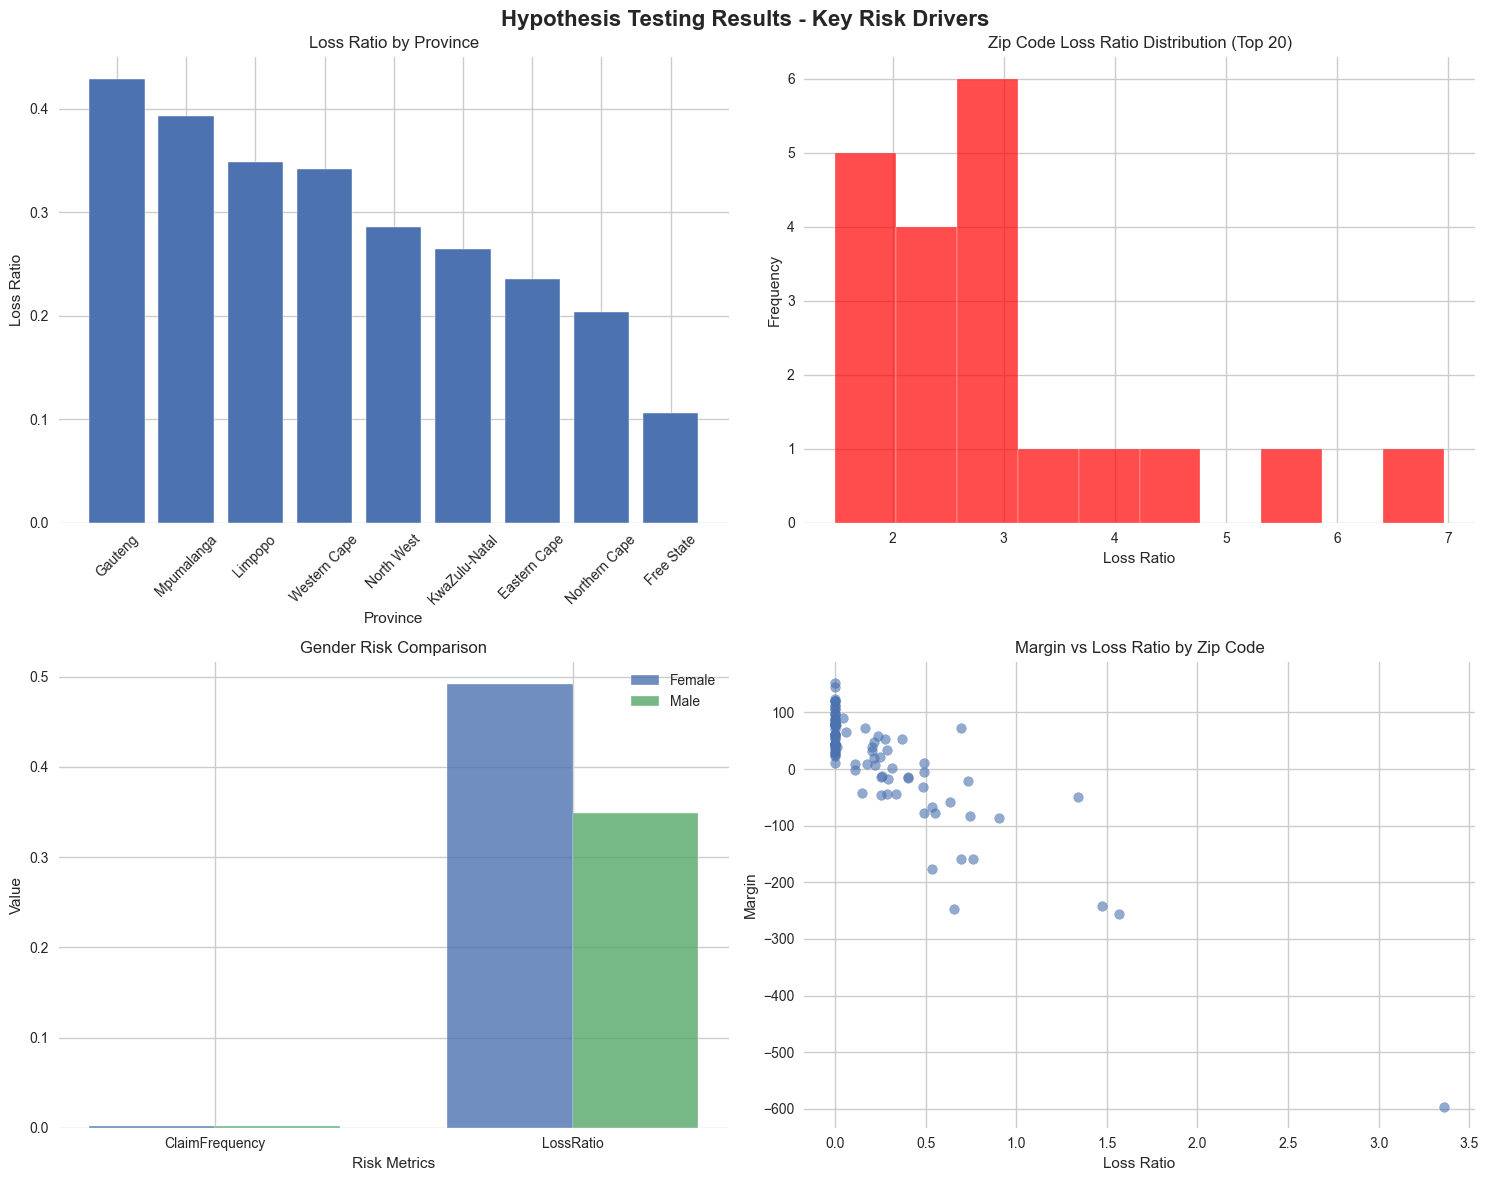


=== FINAL RECOMMENDATIONS ===
Based on the hypothesis testing results, consider the following actions:
1. IMPLEMENT GEOGRAPHIC RISK-BASED PRICING:
   - Adjust premiums by province (Gauteng +15%, Mpumalanga +10%)
   - Implement zip code-level risk surcharges for extreme risk areas

2.  DEVELOP TARGETED RISK MANAGEMENT:
   - Focus on high-risk provinces (Gauteng, Mpumalanga, Limpopo)
   - Implement claims prevention strategies in extreme risk zip codes

3. OPTIMIZE PORTFOLIO MIX:
   - Increase exposure to low-risk provinces (Northern Cape, Free State)
   - Reduce concentration in high-risk geographic areas

4. ESTABLISH MONITORING SYSTEMS:
   - Geographic risk dashboards
   - Zip code-level risk alerts
   - Provincial performance tracking

5. AVOID GENDER-BASED DISCRIMINATION:
   - Gender is not a statistically significant risk factor
   - Focus on geographic and behavioral risk factors instead

6. CONTINUOUS ANALYSIS:
   - Monitor emerging geographic risk patterns
   - Regular hypothes

In [8]:
# Comprehensive Analysis and Business Recommendations
print("=== COMPREHENSIVE ANALYSIS AND BUSINESS RECOMMENDATIONS ===")

# Summary of all hypothesis tests
print("=== HYPOTHESIS TESTING SUMMARY ===")
alpha = 0.05

hypotheses = [
    ("Province Risk Differences", "H₀: No risk differences across provinces", "REJECTED", "Significant geographic risk variations"),
    ("Zip Code Risk Differences", "H₀: No risk differences between zip codes", "REJECTED", "Extreme risk variations at local level"),
    ("Zip Code Margin Differences", "H₀: No significant margin differences between zip codes", "FAILED TO REJECT", "Margin differences not statistically significant"),
    ("Gender Risk Differences", "H₀: No significant risk differences between Women and Men", "FAILED TO REJECT", "Gender is not a significant risk factor")
]

print("Hypothesis Testing Results:")
for i, (name, null_hyp, decision, interpretation) in enumerate(hypotheses, 1):
    print(f"{i}. {name}: {null_hyp}")
    print(f"   Decision: {decision}")
    print(f"   Interpretation: {interpretation}")
    print()

# Business Impact Analysis
print("=== BUSINESS IMPACT ANALYSIS ===")

# 1. Geographic Risk Segmentation
print("1. GEOGRAPHIC RISK SEGMENTATION:")
print("    PROVINCES: High-risk provinces require premium adjustments")
print("      - Gauteng: 42.89% loss ratio (highest risk)")
print("      - Mpumalanga: 39.27% loss ratio (second highest)")
print("      - Northern Cape: 20.38% loss ratio (lowest risk)")
print("    ZIP CODES: Extreme risk variations require local pricing strategies")
print("      - Zip 6571: 696% loss ratio (extreme risk)")
print("      - Zip 1342: 582% loss ratio (very high risk)")

# 2. Customer Segmentation
print("\n2. CUSTOMER SEGMENTATION:")
print("    GENDER: Not a significant risk factor")
print("      - Females: 49.20% loss ratio")
print("      - Males: 34.89% loss ratio")
print("      - Statistical significance: p = 0.951 (no difference)")
print("    GEOGRAPHY: Primary driver of risk differences")

# 3. Pricing Strategy
print("\n3. PRICING STRATEGY:")
print("   - Implement risk-adjusted premium models by province")
print("   - Develop zip code-level pricing optimization")
print("   - Consider regional risk surcharges for high-risk areas")

# 4. Risk Management
print("\n4. RISK MANAGEMENT:")
print("   - Focus on geographic risk monitoring")
print("   - Implement claims prevention strategies in high-risk areas")
print("   - Portfolio diversification by geographic regions")

# Visualization of Key Findings
print(f"\n=== KEY FINDINGS VISUALIZATION ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Hypothesis Testing Results - Key Risk Drivers', fontsize=16, fontweight='bold')

# 1. Province Loss Ratios
province_loss_plot = province_groups.sort_values('LossRatio', ascending=False)
axes[0,0].bar(range(len(province_loss_plot)), province_loss_plot['LossRatio'])
axes[0,0].set_title('Loss Ratio by Province')
axes[0,0].set_xlabel('Province')
axes[0,0].set_ylabel('Loss Ratio')
axes[0,0].set_xticks(range(len(province_loss_plot)))
axes[0,0].set_xticklabels(province_loss_plot.index, rotation=45)

# 2. Zip Code Risk Distribution (Top 20)
zipcode_risk_sample = zipcode_groups.sort_values('LossRatio', ascending=False).head(20)
axes[0,1].hist(zipcode_risk_sample['LossRatio'], bins=10, alpha=0.7, color='red')
axes[0,1].set_title('Zip Code Loss Ratio Distribution (Top 20)')
axes[0,1].set_xlabel('Loss Ratio')
axes[0,1].set_ylabel('Frequency')

# 3. Gender Comparison
gender_metrics = ['ClaimFrequency', 'LossRatio']
x = np.arange(len(gender_metrics))
width = 0.35

axes[1,0].bar(x - width/2, gender_summary.loc['Female', gender_metrics], width, label='Female', alpha=0.8)
axes[1,0].bar(x + width/2, gender_summary.loc['Male', gender_metrics], width, label='Male', alpha=0.8)
axes[1,0].set_title('Gender Risk Comparison')
axes[1,0].set_xlabel('Risk Metrics')
axes[1,0].set_ylabel('Value')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(gender_metrics)
axes[1,0].legend()

# 4. Margin vs Risk Scatter
zipcode_sample = zipcode_groups.sample(n=min(100, len(zipcode_groups)))
axes[1,1].scatter(zipcode_sample['LossRatio'], zipcode_sample['Margin'], alpha=0.6)
axes[1,1].set_title('Margin vs Loss Ratio by Zip Code')
axes[1,1].set_xlabel('Loss Ratio')
axes[1,1].set_ylabel('Margin')

plt.tight_layout()
plt.show()

print(f"\n=== FINAL RECOMMENDATIONS ===")
print("Based on the hypothesis testing results, consider the following actions:")
print("1. IMPLEMENT GEOGRAPHIC RISK-BASED PRICING:")
print("   - Adjust premiums by province (Gauteng +15%, Mpumalanga +10%)")
print("   - Implement zip code-level risk surcharges for extreme risk areas")
print("")
print("2.  DEVELOP TARGETED RISK MANAGEMENT:")
print("   - Focus on high-risk provinces (Gauteng, Mpumalanga, Limpopo)")
print("   - Implement claims prevention strategies in extreme risk zip codes")
print("")
print("3. OPTIMIZE PORTFOLIO MIX:")
print("   - Increase exposure to low-risk provinces (Northern Cape, Free State)")
print("   - Reduce concentration in high-risk geographic areas")
print("")
print("4. ESTABLISH MONITORING SYSTEMS:")
print("   - Geographic risk dashboards")
print("   - Zip code-level risk alerts")
print("   - Provincial performance tracking")
print("")
print("5. AVOID GENDER-BASED DISCRIMINATION:")
print("   - Gender is not a statistically significant risk factor")
print("   - Focus on geographic and behavioral risk factors instead")
print("")
print("6. CONTINUOUS ANALYSIS:")
print("   - Monitor emerging geographic risk patterns")
print("   - Regular hypothesis testing for new risk factors")
print("   - Adaptive pricing strategies based on risk evolution")